#### Import Libraries

In [282]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.metrics import classification_report

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jacquelinemcginley/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jacquelinemcginley/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/jacquelinemcginley/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

#### Load Data

In [283]:
yelp = pd.read_csv("hotel_final.csv")

yelp.head()

,Unnamed: 0,reviewID,reviewContent,rating,usefulCount,coolCount,funnyCount
0,2982,-ZkzDLAp-6LSdek-nU,My husband took me to stay the night for a fun...,4,0,0,0
1,2983,9yStfyRS5CISu-May43dmA,"stayed at the property over the weekend, got a...",3,0,0,0
2,2984,Wf-7bJszS2n6REXGbrwK2w,"Overall, I think I'm less and less a fan of th...",3,0,0,0
3,2985,ZLe,I'd like to make a confession. I don't really ...,3,21,11,16
4,2986,vURf9AGmThDrRC9TVcQrdw,The good: the view; location The bad: servic...,1,0,0,0


#### Inspect Data

In [284]:
print(yelp.shape)
print(yelp.columns)
yelp.info()
yelp.head()

(949, 7)
Index(['Unnamed: 0', 'reviewID', 'reviewContent', 'rating', 'usefulCount',
       'coolCount', 'funnyCount'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     949 non-null    int64 
 1   reviewID       949 non-null    object
 2   reviewContent  949 non-null    object
 3   rating         949 non-null    int64 
 4   usefulCount    949 non-null    int64 
 5   coolCount      949 non-null    int64 
 6   funnyCount     949 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 52.0+ KB


,Unnamed: 0,reviewID,reviewContent,rating,usefulCount,coolCount,funnyCount
0,2982,-ZkzDLAp-6LSdek-nU,My husband took me to stay the night for a fun...,4,0,0,0
1,2983,9yStfyRS5CISu-May43dmA,"stayed at the property over the weekend, got a...",3,0,0,0
2,2984,Wf-7bJszS2n6REXGbrwK2w,"Overall, I think I'm less and less a fan of th...",3,0,0,0
3,2985,ZLe,I'd like to make a confession. I don't really ...,3,21,11,16
4,2986,vURf9AGmThDrRC9TVcQrdw,The good: the view; location The bad: servic...,1,0,0,0


#### Check for  Missing Values

In [285]:
yelp.isnull().sum()

Unnamed: 0       0
reviewID         0
reviewContent    0
rating           0
usefulCount      0
coolCount        0
funnyCount       0
dtype: int64

#### Create Sentiment Groups

In [286]:
def sentGroup(rating):
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return "Neutral"

yelp["sentGroup"] = yelp["rating"].apply(sentGroup)

yelp["sentGroup"].value_counts()

sentGroup
Positive    540
Neutral     207
Negative    202
Name: count, dtype: int64

#### Visualize Rating  Distribution

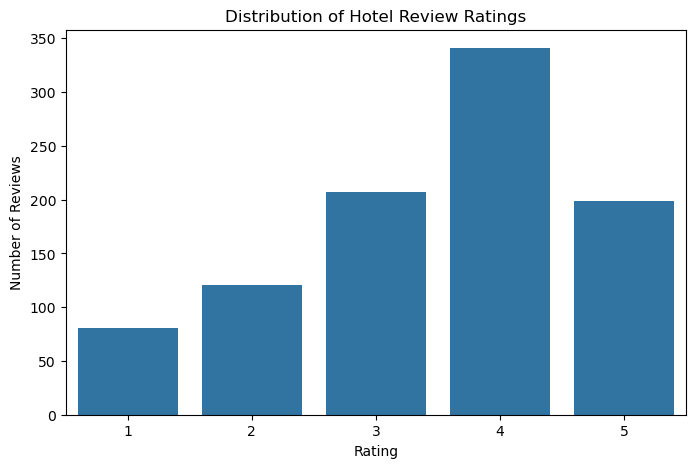

In [287]:
plt.figure(figsize = (8, 5))
sns.countplot(data = yelp, x = "rating")
plt.title("Distribution of Hotel Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

#### Visualize Sentiment Distribution

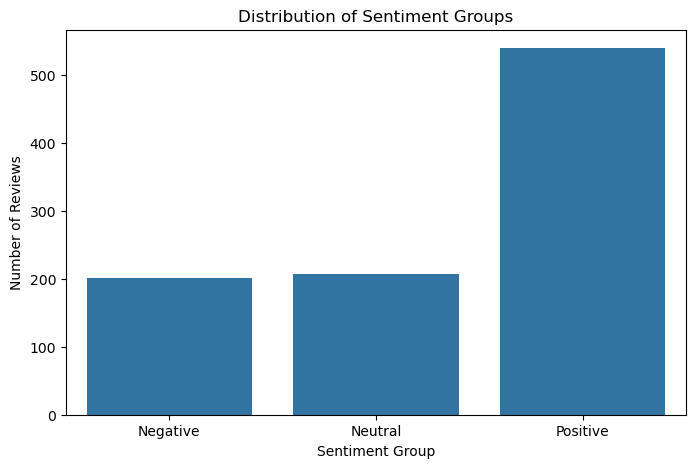

In [288]:
plt.figure(figsize = (8, 5))
sns.countplot(data = yelp, x = "sentGroup", order=["Negative", "Neutral", "Positive"])
plt.title("Distribution of Sentiment Groups")
plt.xlabel("Sentiment Group")
plt.ylabel("Number of Reviews")
plt.show()

#### Clean Review Text

In [289]:
stopWords = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

customStopwords = {
    "hotel", "room", "stay", "stayed", "night", "place", "would",
    "could", "also", "one", "get", "us", "like"
}

stopWords = stopWords.union(customStopwords)

def cleanText(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stopWords and len(word) > 2
    ]
    
    return " ".join(words)

yelp["cleanReview"] = yelp["reviewContent"].apply(cleanText)

yelp[["reviewContent", "cleanReview"]].head()

,reviewContent,cleanReview
0,My husband took me to stay the night for a fun...,husband took fun date year finally getting aro...
1,"stayed at the property over the weekend, got a...",property weekend got fantastic rate priceline ...
2,"Overall, I think I'm less and less a fan of th...",overall think less less fan concept good bad r...
3,I'd like to make a confession. I don't really ...,make confession really hotel much really whate...
4,The good: the view; location The bad: servic...,good view location bad service non existent ru...


#### Split Data Between Negative, Neutral, and  Positive

In [290]:
positive = yelp[yelp["sentGroup"] == "Positive"].copy()
negative = yelp[yelp["sentGroup"] == "Negative"].copy()
neutral = yelp[yelp["sentGroup"] == "Neutral"].copy()

print("Positive:", positive.shape)
print("Negative:", negative.shape)
print("Neutral:", neutral.shape)

Positive: (540, 9)
Negative: (202, 9)
Neutral: (207, 9)


#### Create Function for Top Words

In [291]:
def getTopWords(textSeries, n = 20):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(textSeries)
    
    wordCounts = X.sum(axis = 0).A1
    words = vectorizer.get_feature_names_out()
    
    wordFreq = pd.DataFrame({
        "word": words,
        "count": wordCounts
    }).sort_values(by = "count", ascending = False)
    
    return wordFreq.head(n)

#### Identify Top Words in Total Dataset

In [292]:
topWords = getTopWords(yelp["cleanReview"], n = 20)
topWords

,word,count
2808,great,637
5368,room,549
4212,nice,500
1067,chicago,464
3697,lobby,460
5593,service,447
6486,time,438
567,bed,408
2761,good,393
3702,location,361


#### Visualize Top Words of Full Cleaned Dataset

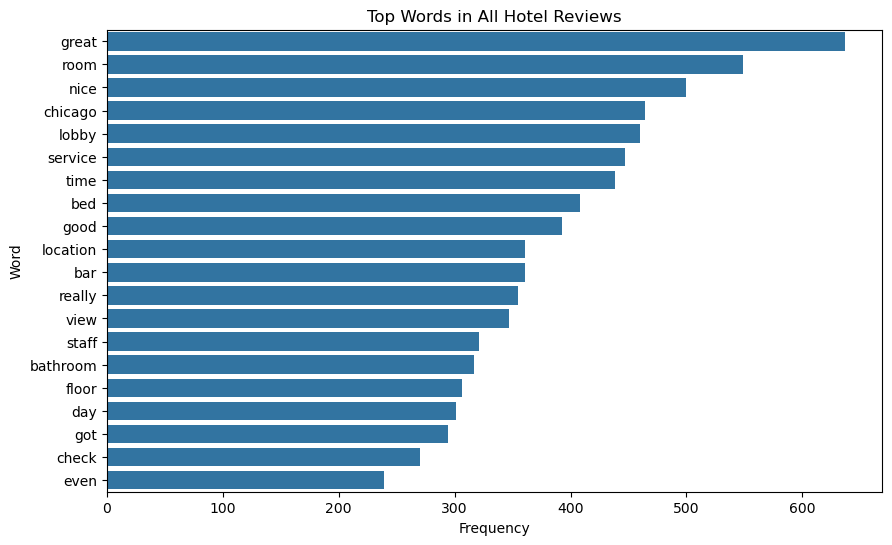

In [293]:
plt.figure(figsize = (10, 6))
sns.barplot(data = topWords, x = "count", y = "word")
plt.title("Top Words in All Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

#### Top Words in Positive Reviews

In [294]:
topWordsPos = getTopWords(positive["cleanReview"], n = 20)
topWordsPos

,word,count
1938,great,447
737,chicago,290
3715,room,285
2910,nice,280
2528,lobby,260
4494,time,235
1906,good,228
333,bar,221
4767,view,215
3870,service,215


#### Visualize Positive Words

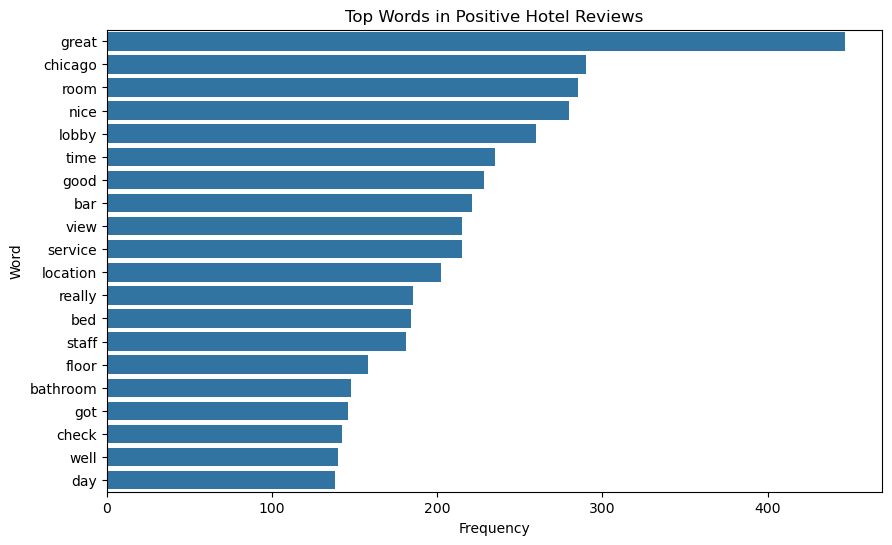

In [295]:
plt.figure(figsize = (10, 6))
sns.barplot(data = topWordsPos, x = "count", y = "word")
plt.title("Top Words in Positive Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

#### Top Words in Negative Reviews

In [296]:
topWordsNeg = getTopWords(negative["cleanReview"], n = 20)
topWordsNeg

,word,count
2841,service,152
2731,room,110
312,bed,108
885,desk,104
3284,time,98
819,day,97
1878,lobby,91
1346,front,90
1422,got,86
258,back,82


#### Visualize Negative Words

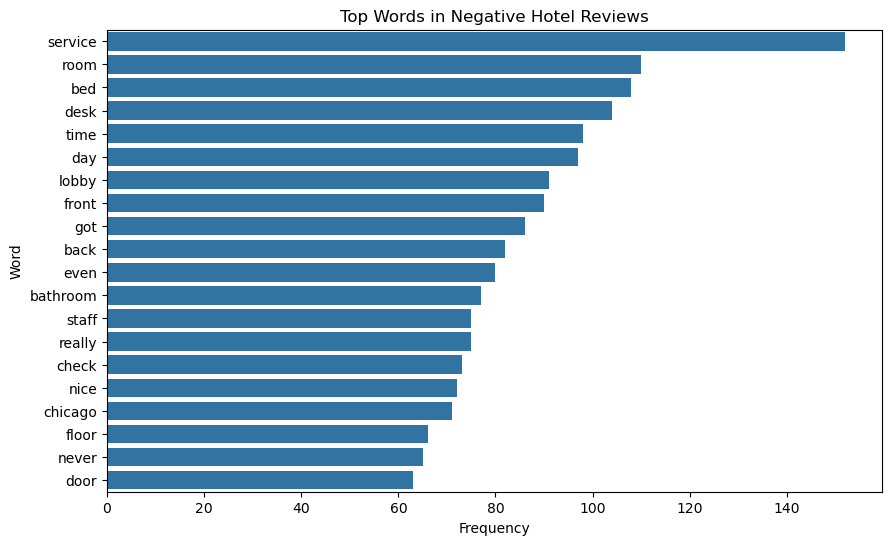

In [297]:
plt.figure(figsize = (10, 6))
sns.barplot(data = topWordsNeg, x = "count", y = "word")
plt.title("Top Words in Negative Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

#### Creat Function for Top N-Grams

In [298]:
def getTopNgrams(text_series, ngram_range = (2, 2), n = 20):
    vectorizer = CountVectorizer(ngram_range = ngram_range)
    X = vectorizer.fit_transform(text_series)
    
    counts = X.sum(axis = 0).A1
    phrases = vectorizer.get_feature_names_out()
    
    phrase_freq = pd.DataFrame({
        "phrase": phrases,
        "count": counts
    }).sort_values(by="count", ascending=False)
    
    return phrase_freq.head(n)

#### Identify Top Bigrams in Positive Reviews

In [299]:
posBigrams = getTopNgrams(
    positive["cleanReview"],
    ngram_range = (2, 2),
    n = 20
)

posBigrams

,phrase,count
17365,palmer house,113
16072,navy pier,55
9898,front desk,51
10877,great location,45
10955,great view,35
26121,walking distance,34
13922,lobby bar,31
19477,really nice,28
25841,view lake,28
15446,michigan ave,25


#### Visualize Positive Bigrams

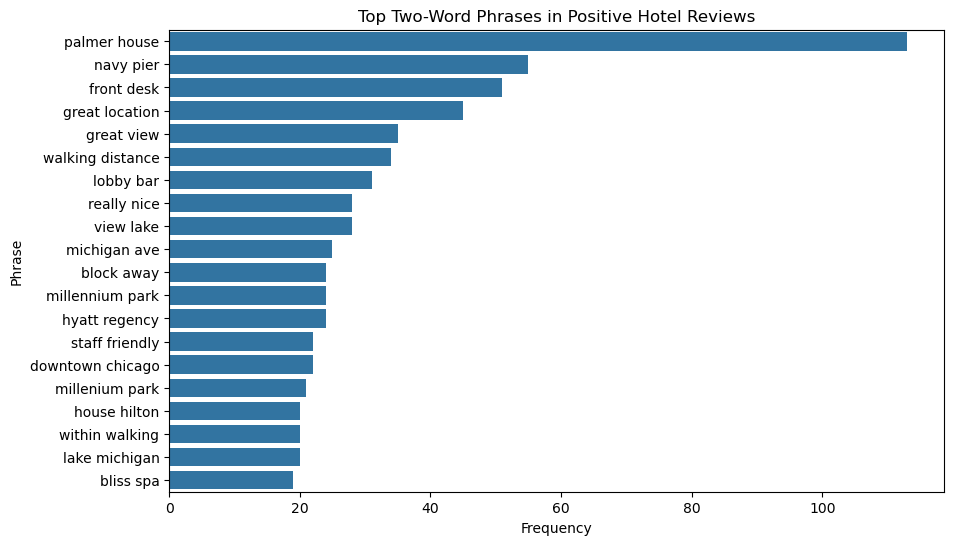

In [300]:
plt.figure(figsize = (10, 6))
sns.barplot(data = posBigrams, x = "count", y = "phrase")
plt.title("Top Two-Word Phrases in Positive Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Phrase")
plt.show()

#### Identify Top Bigrams in Negative Reviews

In [301]:
negBigrams = getTopNgrams(
    negative["cleanReview"],
    ngram_range = (2, 2),
    n = 20
)

negBigrams

,phrase,count
5333,front desk,76
9361,palmer house,40
3179,customer service,21
1897,came back,12
8955,non smoking,12
4327,even though,12
3854,double bed,11
2649,come back,11
11016,room small,11
8826,next door,11


#### Visuzalize Negative Bigrams

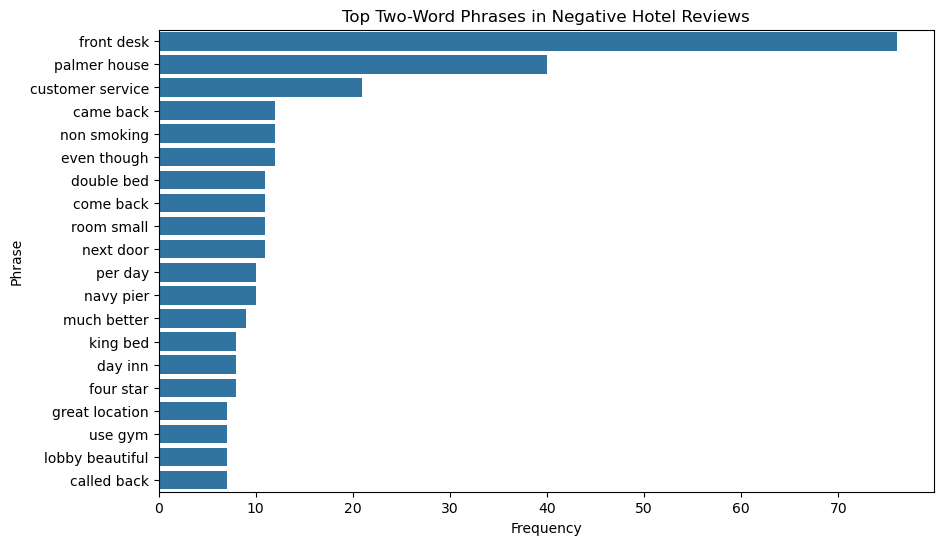

In [302]:
plt.figure(figsize = (10, 6))
sns.barplot(data = negBigrams, x = "count", y = "phrase")
plt.title("Top Two-Word Phrases in Negative Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Phrase")
plt.show()

#### Incorporate Review Length Feature

In [303]:
yelp["reviewWordCount"] = yelp["cleanReview"].apply(lambda x: len(x.split()))
yelp["reviewCharCount"] = yelp["reviewContent"].apply(lambda x: len(str(x)))

yelp[["rating", "sentGroup", "reviewWordCount", "reviewCharCount"]].head()

,rating,sentGroup,reviewWordCount,reviewCharCount
0,4,Positive,95,1203
1,3,Neutral,175,2056
2,3,Neutral,50,666
3,3,Neutral,216,2845
4,1,Negative,43,383


#### Compare Review Length By Sentiment

In [304]:
yelp.groupby("sentGroup")[["reviewWordCount", "reviewCharCount"]].mean()

,reviewWordCount,reviewCharCount
sentGroup,,
Negative,84.529703,1074.084158
Neutral,75.241546,940.772947
Positive,62.805556,769.522222


#### Visualize Review Length By Sentiment

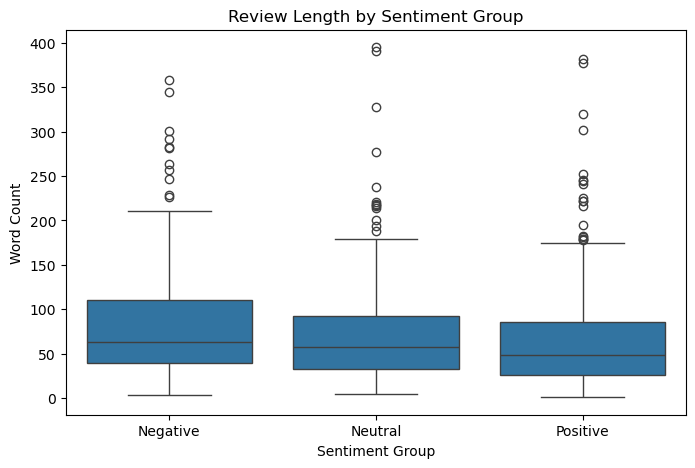

In [305]:
plt.figure(figsize = (8, 5))
sns.boxplot(data = yelp, x = "sentGroup", y = "reviewWordCount", order = ["Negative", "Neutral", "Positive"])
plt.title("Review Length by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Word Count")
plt.show()

#### Create Topic Modeling Function Using LDA

In [306]:
def run_lda_topic_model(text_series, num_topics = 5, num_words = 10):
    vectorizer = CountVectorizer(
        max_df = 0.90,
        min_df = 5,
        stop_words = "english"
    )
    
    X = vectorizer.fit_transform(text_series)
    
    lda = LatentDirichletAllocation(
        n_components = num_topics,
        random_state = 13,
        learning_method = "batch"
    )
    
    lda.fit(X)
    
    feature_names = vectorizer.get_feature_names_out()
    
    topics = []
    
    for topic_num, topic in enumerate(lda.components_):
        top_word_indices = topic.argsort()[-num_words:][::-1]
        top_words = [feature_names[i] for i in top_word_indices]
        
        topics.append({
            "topic_number": topic_num + 1,
            "top_words": ", ".join(top_words)
        })
    
    topic = pd.DataFrame(topics)
    
    topicMatrix = lda.transform(X)
    
    return lda, vectorizer, topic, topicMatrix

#### LDA Topics for All Reviews

In [307]:
ldaTotal, vectorizerTotal, topicsTotal, topicsTotalMatrix = run_lda_topic_model(
    yelp["cleanReview"],
    num_topics = 5,
    num_words = 12
)

topicsTotal

,topic_number,top_words
0,1,"wedding, great, nice, got, house, time, really..."
1,2,"bed, time, room, service, door, desk, bathroom..."
2,3,"great, room, nice, bed, lobby, location, bathr..."
3,4,"service, got, desk, time, check, day, guest, k..."
4,5,"great, chicago, good, lobby, bar, room, locati..."


#### LDA Topics for Positive Reviews

In [308]:
ldaPos, vectorizerPos, topicsPos, topicsPosMatrix = run_lda_topic_model(
    positive["cleanReview"],
    num_topics = 5,
    num_words = 12
)

topicsPos

,topic_number,top_words
0,1,"wedding, lobby, good, time, room, great, palme..."
1,2,"room, chicago, great, lobby, nice, location, s..."
2,3,"service, location, view, bar, lake, lobby, are..."
3,4,"great, chicago, hyatt, nice, location, time, s..."
4,5,"great, view, nice, lake, bed, bathroom, time, ..."


#### LDA Topics for Negative Reviews

In [309]:

ldaNeg, vectorizerNeg, topicsNeg, topicsNegMatrix = run_lda_topic_model(
    negative["cleanReview"],
    num_topics = 5,
    num_words = 12
)

topicsNeg

,topic_number,top_words
0,1,"room, lobby, desk, service, guest, check, elev..."
1,2,"bed, desk, service, bag, check, bathroom, guy,..."
2,3,"service, staff, time, work, come, got, desk, r..."
3,4,"time, door, day, really, room, wall, lobby, se..."
4,5,"bed, day, parking, view, bathroom, star, got, ..."


#### Add Dominant Topic to Negative Reviews

In [310]:
negative = negative.reset_index(drop = True)

negative["dominantTopic"] = topicsNegMatrix.argmax(axis = 1) + 1

negative[["rating", "cleanReview", "dominantTopic"]].head()

,rating,cleanReview,dominantTopic
0,1,good view location bad service non existent ru...,1
1,1,location atmosphere nice room comfy great view...,5
2,2,first time staying probably last booked holida...,2
3,2,truly disapointed great lake view navu pier we...,5
4,2,pro view lake michigan food solid combined out...,1


#### Count Dominant Negative Topics

In [311]:
negTopicCount = negative["dominantTopic"].value_counts().sort_index()

negTopicCount

dominantTopic
1    24
2    51
3    54
4    32
5    41
Name: count, dtype: int64

#### Visualize Dominant Negative Topics

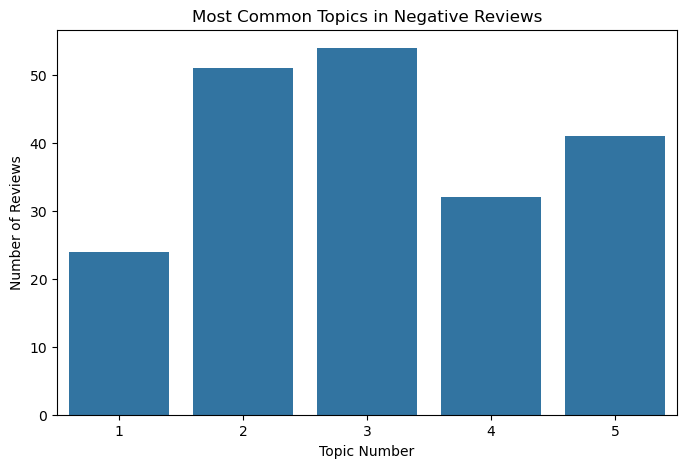

In [312]:
plt.figure(figsize = (8, 5))
sns.barplot(x = negTopicCount.index, y = negTopicCount.values)
plt.title("Most Common Topics in Negative Reviews")
plt.xlabel("Topic Number")
plt.ylabel("Number of Reviews")
plt.show()

In [313]:
negTopicLabels = {
    1: "Service Breakdown/Attitude",
    2: "Cleanliness/Wear/Poor Upkeep",
    3: "Design Flaws/Lack of Privacy",
    4: "Noise/Atmosphere Problem",
    5: "Price/Fees/Poor Value"
}

negative["topicLabel"] = negative["dominantTopic"].map(negTopicLabels)

negative[["dominantTopic", "topicLabel", "cleanReview"]].head()

,dominantTopic,topicLabel,cleanReview
0,1,Service Breakdown/Attitude,good view location bad service non existent ru...
1,5,Price/Fees/Poor Value,location atmosphere nice room comfy great view...
2,2,Cleanliness/Wear/Poor Upkeep,first time staying probably last booked holida...
3,5,Price/Fees/Poor Value,truly disapointed great lake view navu pier we...
4,1,Service Breakdown/Attitude,pro view lake michigan food solid combined out...


#### Visualize Labeled Negative Topics

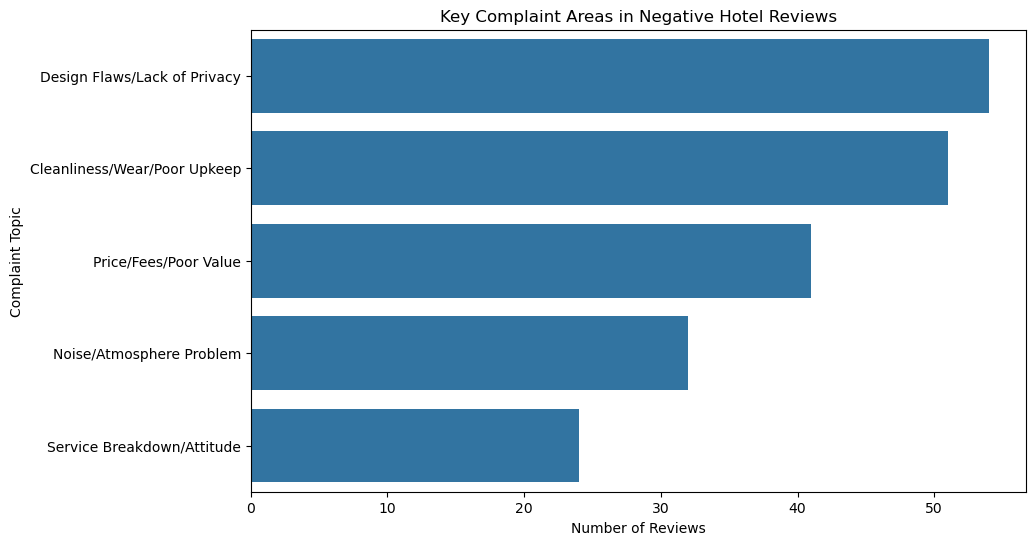

In [314]:
topicLabelCount = negative["topicLabel"].value_counts()

plt.figure(figsize = (10, 6))
sns.barplot(x = topicLabelCount.values, y = topicLabelCount.index)
plt.title("Key Complaint Areas in Negative Hotel Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Complaint Topic")
plt.show()

#### Topic Modeling Function using TF-IDF + NMF

In [315]:
def run_nmf_topic_model(text_series, num_topics = 5, num_words = 10):
    vectorizer = TfidfVectorizer(
        max_df = 0.90,
        min_df = 5,
        stop_words="english"
    )
    
    X = vectorizer.fit_transform(text_series)
    
    nmf = NMF(
        n_components = num_topics,
        random_state = 13
    )
    
    nmf.fit(X)
    
    featureNames = vectorizer.get_feature_names_out()
    
    topics = []
    
    for topicNum, topic in enumerate(nmf.components_):
        topWordIndices = topic.argsort()[-num_words:][::-1]
        topWords = [featureNames[i] for i in topWordIndices]
        
        topics.append({
            "topic_number": topicNum + 1,
            "top_words": ", ".join(topWords)
        })
    
    topicData = pd.DataFrame(topics)
    
    topicMatrix = nmf.transform(X)
    
    return nmf, vectorizer, topicData, topicMatrix

#### NMF Topics for Positive Reviews

In [316]:
nmfPos, tfidfPos, nmfTopicsPos, nmfTopicsPos = run_nmf_topic_model(
    positive["cleanReview"],
    num_topics = 5,
    num_words = 12
)

nmfTopicsPos

array([[0.07323923, 0.01983129, 0.01914776, 0.12282776, 0.03747788],
       [0.        , 0.16853488, 0.11632146, 0.        , 0.01203825],
       [0.04946343, 0.15305496, 0.01736766, 0.02796816, 0.        ],
       ...,
       [0.10689952, 0.03948174, 0.        , 0.12094527, 0.        ],
       [0.01802632, 0.05850594, 0.        , 0.08594037, 0.05527553],
       [0.        , 0.15514544, 0.        , 0.23422484, 0.        ]],
      shape=(540, 5))

#### NMF Topics for Negative Reviews

In [317]:
nmfNeg, tfidfNeg, nmfTopicsNeg, nmfTopicsNeg = run_nmf_topic_model(
    negative["cleanReview"],
    num_topics = 5,
    num_words = 12
)

nmfTopicsNeg

array([[0.10547241, 0.        , 0.        , 0.21186626, 0.        ],
       [0.06965896, 0.12017659, 0.01913427, 0.04243528, 0.0007357 ],
       [0.08875973, 0.03631734, 0.16586609, 0.        , 0.        ],
       ...,
       [0.08241367, 0.        , 0.2286166 , 0.04898765, 0.        ],
       [0.142011  , 0.03358464, 0.01223377, 0.        , 0.        ],
       [0.13154122, 0.        , 0.        , 0.        , 0.        ]],
      shape=(202, 5))

#### Compare Average Review Length By Rating

In [318]:
lengthByRating = yelp.groupby("rating")["reviewWordCount"].mean().reset_index()

lengthByRating

,rating,reviewWordCount
0,1,83.061728
1,2,85.512397
2,3,75.241546
3,4,63.920821
4,5,60.894472


#### Plot Average Review Length By Rating

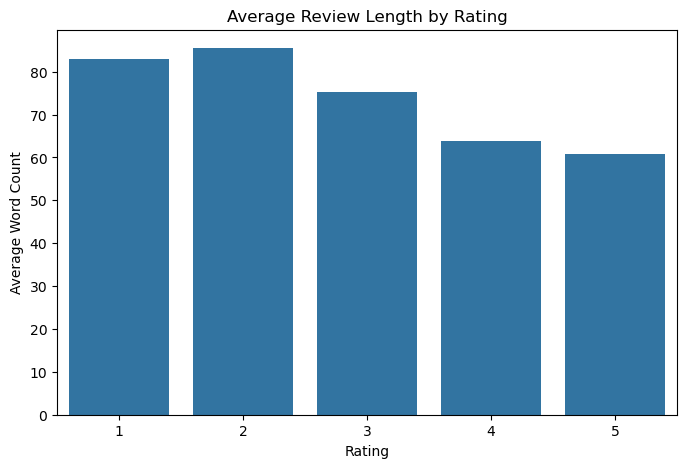

In [319]:
plt.figure(figsize = (8, 5))
sns.barplot(data = lengthByRating, x = "rating", y = "reviewWordCount")
plt.title("Average Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Word Count")
plt.show()

#### Identify Common Complaint Phrases Manually

In [320]:
complaintTerms = [
    "dirty",
    "rude",
    "noise",
    "smell",
    "parking",
    "bathroom",
    "bed",
    "service",
    "staff",
    "front desk",
    "fee",
    "expensive",
    "broken",
    "clean"
]

for term in complaintTerms:
    yelp[f"mentions_{term.replace(' ', '_')}"] = yelp["cleanReview"].str.contains(term, regex = False)

#### Compare Complaint Term Mentions By Sentiment

In [321]:
complaintSummary = []

for term in complaintTerms:
    col = f"mentions_{term.replace(' ', '_')}"
    
    summary = yelp.groupby("sentGroup")[col].mean().reset_index()
    summary["term"] = term
    complaintSummary.append(summary)

complaintSummaryData = pd.concat(complaintSummary)

complaintSummaryData.head()

,sentGroup,mentions_dirty,term,mentions_rude,mentions_noise,mentions_smell,mentions_parking,mentions_bathroom,mentions_bed,mentions_service,mentions_staff,mentions_front_desk,mentions_fee,mentions_expensive,mentions_broken,mentions_clean
0,Negative,0.079208,dirty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Neutral,0.014493,dirty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Positive,0.003704,dirty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,rude,0.094059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Neutral,NaN,rude,0.019324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [322]:
# 43. Show complaint terms for negative reviews only

negComplaintRates = complaintSummaryData[
    complaintSummaryData["sentGroup"] == "Negative"
].copy()

negComplaintRates = negComplaintRates.rename(columns = {0: "mentionRate"})

negComplaintRates

,sentGroup,mentions_dirty,term,mentions_rude,mentions_noise,mentions_smell,mentions_parking,mentions_bathroom,mentions_bed,mentions_service,mentions_staff,mentions_front_desk,mentions_fee,mentions_expensive,mentions_broken,mentions_clean
0,Negative,0.079208,dirty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,rude,0.094059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,noise,NaN,0.064356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,smell,NaN,NaN,0.064356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,parking,NaN,NaN,NaN,0.133663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,bathroom,NaN,NaN,NaN,NaN,0.257426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,bed,NaN,NaN,NaN,NaN,NaN,0.331683,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,service,NaN,NaN,NaN,NaN,NaN,NaN,0.391089,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,staff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.247525,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,front desk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.257426,NaN,NaN,NaN,NaN


#### Cleaner Complaint Rate Table

In [323]:
complaintRateTable = []

for term in complaintTerms:
    col = f"mentions_{term.replace(' ', '_')}"
    
    complaintRateTable.append({
        "term": term,
        "negMentionRate": negative["cleanReview"].str.contains(term, regex = False).mean(),
        "posMentionRate": positive["cleanReview"].str.contains(term, regex = False).mean()
    })

complaintRateTable = pd.DataFrame(complaintRateTable)

complaintRateTable["diffNegPos"] = (
    complaintRateTable["negMentionRate"] 
    - complaintRateTable["posMentionRate"]
)

complaintRateTable = complaintRateTable.sort_values(
    by = "diffNegPos",
    ascending = False
)

complaintRateTable

,term,negMentionRate,posMentionRate,diffNegPos
9,front desk,0.257426,0.081481,0.175944
7,service,0.391089,0.296296,0.094793
1,rude,0.094059,0.007407,0.086652
0,dirty,0.079208,0.003704,0.075504
12,broken,0.064356,0.000000,0.064356
10,fee,0.257426,0.205556,0.051870
3,smell,0.064356,0.020370,0.043986
11,expensive,0.094059,0.051852,0.042208
2,noise,0.064356,0.024074,0.040282
4,parking,0.133663,0.098148,0.035515


#### Visualize  Terms That Appear More In Negative Reviews

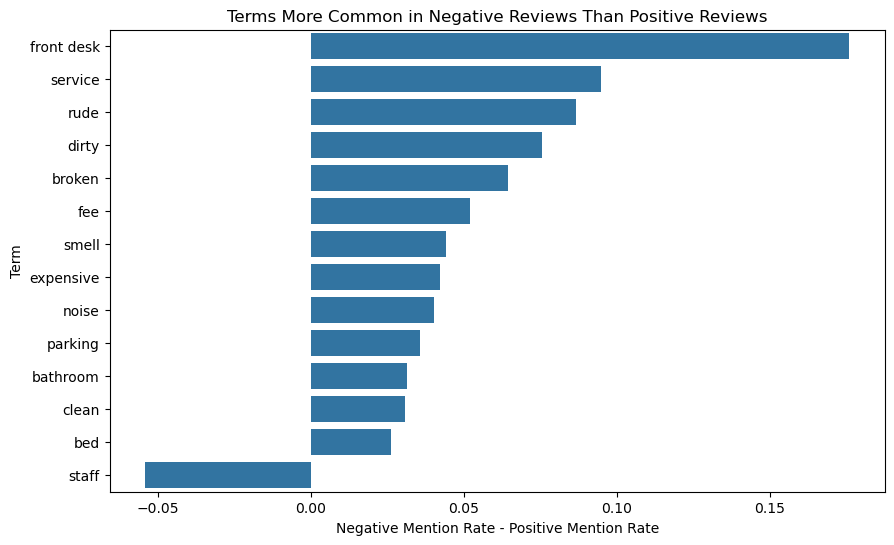

In [324]:
plt.figure(figsize = (10, 6))
sns.barplot(
    data = complaintRateTable,
    x="diffNegPos",
    y="term"
)

plt.title("Terms More Common in Negative Reviews Than Positive Reviews")
plt.xlabel("Negative Mention Rate - Positive Mention Rate")
plt.ylabel("Term")
plt.show()

#### Pull Example Reviews For Each Negative Topic

In [325]:
for topic in sorted(negative["dominantTopic"].unique()):
    print("=" * 80)
    print(f"Topic {topic}: {negTopicLabels.get(topic, 'Unlabeled Topic')}")
    print("=" * 80)
    
    examples = negative[negative["dominantTopic"] == topic]["reviewContent"].head(3)
    
    for i, review in enumerate(examples, start = 1):
        print(f"\nExample {i}:")
        print(review[:700])

Topic 1: Service Breakdown/Attitude

Example 1:
The good:  the view; location The bad:  service non-existent (or rude when you get someone's attention) Dirty, dingy, tired rooms (stains on sheets, walls, really foul) Cheap furniture Air conditioning erratic and LOUD Poor lighting (don't even try to shave in the bathroom); dimly lit elevators Constant barrage of music. Very dated atmosphere. So many better choices (and cheaper).

Example 2:
Pros - View of Lake Michigan - Food was solid combined with outdoor seating - Location - great location - close to Navy Pier & Michigan Ave Cons -Rooms/bathroom are small (even with upgrade) -Air-conditioning obscenely loud (according to the wife) -Rooms look dated but they tried hard to update them (Used to be an old Days Inn) -Wife thought the room smelled (1st room was smoky and we got switched; second room has carpet cleaner overkill) -Service was poor - specifically bell desk shuttling us a new key that never happened and I ultimately headed dow

#### Create Summary Tables For Presentation

In [326]:
summaryTable = negative["topicLabel"].value_counts().reset_index()
summaryTable.columns = ["Complaint Topic", "Number of Negative Reviews"]

summaryTable["Percent of Negative Reviews"] = (
    summaryTable["Number of Negative Reviews"] / len(negative) * 100
).round(2)

summaryTable

,Complaint Topic,Number of Negative Reviews,Percent of Negative Reviews
0,Design Flaws/Lack of Privacy,54,26.73
1,Cleanliness/Wear/Poor Upkeep,51,25.25
2,Price/Fees/Poor Value,41,20.30
3,Noise/Atmosphere Problem,32,15.84
4,Service Breakdown/Attitude,24,11.88


#### Export Tables For Slides

In [327]:
topicsTotal.to_csv("topicsAllReviews.csv", index=False)
topicsNeg.to_csv("topicsNegativeReviews.csv", index=False)
topicsPos.to_csv("topicsPositiveReviews.csv", index=False)
summaryTable.to_csv("negReviewTopicSummary.csv", index=False)
complaintRateTable.to_csv("complaintTermComparison.csv", index=False)

In [328]:
# 49. Final executive-style insights template

print("Main Takeaways:")
print("1. Reviewers discuss service, rooms, cleanliness, price, location, and amenities most often.")
print("2. Negative reviews are especially useful because they reveal failure points that can damage brand reputation.")
print("3. Common negative-review topics should guide operational priorities for the new hotel.")
print("4. Management should focus on preventable issues such as cleanliness, front desk service, maintenance, and fee transparency.")

Main Takeaways:
1. Reviewers discuss service, rooms, cleanliness, price, location, and amenities most often.
2. Negative reviews are especially useful because they reveal failure points that can damage brand reputation.
3. Common negative-review topics should guide operational priorities for the new hotel.
4. Management should focus on preventable issues such as cleanliness, front desk service, maintenance, and fee transparency.


In [329]:
# 50. Recommendation framework

recommendations = pd.DataFrame({
    "Finding": [
        "Cleanliness appears frequently in negative reviews",
        "Service/front desk issues are common",
        "Maintenance and bathroom issues appear in complaints",
        "Parking, fees, and value concerns appear in negative reviews",
        "Positive reviews often mention location, comfort, and helpful staff"
    ],
    "Recommendation": [
        "Implement room inspection checklists and housekeeping quality audits",
        "Train front desk staff on service recovery and escalation procedures",
        "Create fast-response maintenance ticket system",
        "Clearly communicate fees before booking and at check-in",
        "Use positive themes in marketing while protecting against negative themes operationally"
    ]
})

recommendations

,Finding,Recommendation
0,Cleanliness appears frequently in negative rev...,Implement room inspection checklists and house...
1,Service/front desk issues are common,Train front desk staff on service recovery and...
2,Maintenance and bathroom issues appear in comp...,Create fast-response maintenance ticket system
3,"Parking, fees, and value concerns appear in ne...",Clearly communicate fees before booking and at...
4,"Positive reviews often mention location, comfo...",Use positive themes in marketing while protect...
